In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Ridge  # Using Ridge regression for better stability

In [5]:
# Load Data
df_train = pd.read_csv('training.csv')
df_test = pd.read_csv('testing.csv')

# Define Features & Target
features = ['AT', 'AP', 'AH', 'AFDP', 'GTEP', 'TIT', 'TAT', 'CDP']
target = 'NOX'

X_train, y_train = df_train[features], df_train[target]
X_test, y_test = df_test[features], df_test[target]

In [6]:
# --- 1. Polynomial Regression for Degrees 2, 3, 5 ---
degrees = [2, 3, 5]
poly_results = {}

for degree in degrees:
    # Create a polynomial regression pipeline
    model = make_pipeline(PolynomialFeatures(degree=degree), Ridge(alpha=1.0)) # Ridge for stability
    model.fit(X_train, y_train)

    # Predict
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluate
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    poly_results[degree] = {
        'r2_train': r2_train,
        'r2_test': r2_test,
        'rmse_train': rmse_train,
        'rmse_test': rmse_test
    }

print("\nPolynomial Regression Results:")
for result in poly_results.items():
    print(result)

d:\MiniMiniConda\envs\MSE413\lib\site-packages\sklearn\linear_model\_ridge.py:211: LinAlgWarning: Ill-conditioned matrix (rcond=1.88669e-21): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T



Polynomial Regression Results:
(2, {'r2_train': 0.7335493718469192, 'r2_test': 0.7284865963373766, 'rmse_train': 6.049432445093668, 'rmse_test': 5.998318166802804})
(3, {'r2_train': 0.7953170922184079, 'r2_test': 0.7877713218035387, 'rmse_train': 5.302089398245053, 'rmse_test': 5.303174231545181})
(5, {'r2_train': 0.8642479668758973, 'r2_test': 0.692346344032845, 'rmse_train': 4.317968088129183, 'rmse_test': 6.385058804205709})


In [7]:
# --- 2. Decision Tree Regression ---
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)

# Predict
y_train_pred_tree = tree_model.predict(X_train)
y_test_pred_tree = tree_model.predict(X_test)

# Evaluate
r2_train_tree = r2_score(y_train, y_train_pred_tree)
r2_test_tree = r2_score(y_test, y_test_pred_tree)
rmse_train_tree = np.sqrt(mean_squared_error(y_train, y_train_pred_tree))
rmse_test_tree = np.sqrt(mean_squared_error(y_test, y_test_pred_tree))

tree_results = {
    'r2_train': r2_train_tree,
    'r2_test': r2_test_tree,
    'rmse_train': rmse_train_tree,
    'rmse_test': rmse_test_tree
}

print(tree_results)

{'r2_train': 1.0, 'r2_test': 0.7388704156866641, 'rmse_train': 1.5509006732360884e-16, 'rmse_test': 5.8824995124017505}


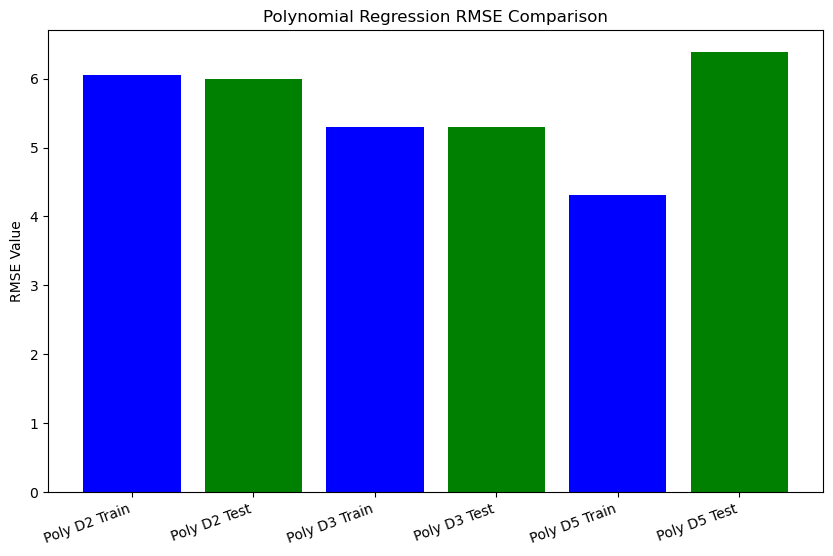

In [8]:
# --- 3. Visualization of RMSE for Polynomial Regression ---
x_labels = ['Poly D2 Train', 'Poly D2 Test', 'Poly D3 Train', 'Poly D3 Test', 'Poly D5 Train', 'Poly D5 Test']
y_values = [
    poly_results[2]['rmse_train'], poly_results[2]['rmse_test'],
    poly_results[3]['rmse_train'], poly_results[3]['rmse_test'],
    poly_results[5]['rmse_train'], poly_results[5]['rmse_test']
]

plt.figure(figsize=(10, 6))
plt.bar(x_labels, y_values, color=['blue', 'green', 'blue', 'green', 'blue', 'green'])
plt.title("Polynomial Regression RMSE Comparison")
plt.ylabel("RMSE Value")
plt.xticks(rotation=20, ha='right')
plt.show()

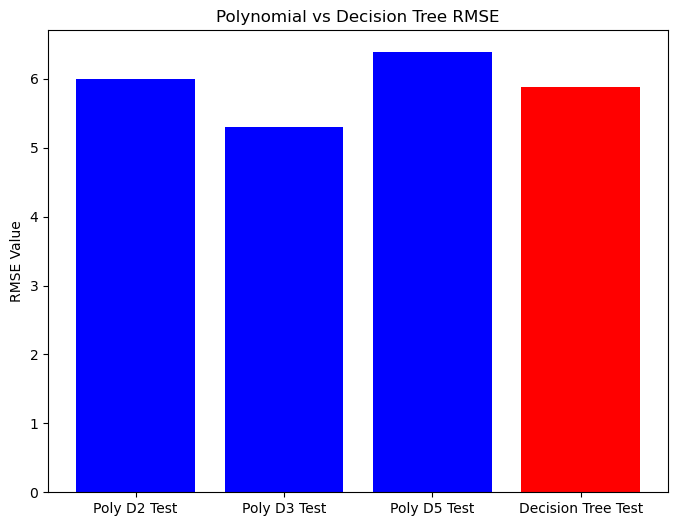

In [9]:
# --- 4. Compare Polynomial Regression vs Decision Tree ---
x_labels = ['Poly D2 Test', 'Poly D3 Test', 'Poly D5 Test', 'Decision Tree Test']
y_values = [
    poly_results[2]['rmse_test'], poly_results[3]['rmse_test'], poly_results[5]['rmse_test'], rmse_test_tree
]

plt.figure(figsize=(8, 6))
plt.bar(x_labels, y_values, color=['blue', 'blue', 'blue', 'red'])
plt.title("Polynomial vs Decision Tree RMSE")
plt.ylabel("RMSE Value")
plt.show()

In [10]:
# --- 5. Overfitting Analysis ---
print("\nOverfitting Analysis:")
print(f"Degree 2 - Train R²: {poly_results[2]['r2_train']:.3f}, Test R²: {poly_results[2]['r2_test']:.3f}")
print(f"Degree 3 - Train R²: {poly_results[3]['r2_train']:.3f}, Test R²: {poly_results[3]['r2_test']:.3f}")
print(f"Degree 5 - Train R²: {poly_results[5]['r2_train']:.3f}, Test R²: {poly_results[5]['r2_test']:.3f}")
print(f"Decision Tree - Train R²: {r2_train_tree:.3f}, Test R²: {r2_test_tree:.3f}")

if poly_results[5]['r2_train'] > 0.95 and poly_results[5]['r2_test'] < poly_results[3]['r2_test']:
    print("\nOverfitting starts at degree 5, as train R² is very high but test R² drops.")

# --- 6. Decision Tree Overfitting Check ---
if r2_train_tree > 0.98 and r2_test_tree < poly_results[3]['r2_test']:
    print("\nDecision Tree is also overfitting (high train R² but low test R²).")



Overfitting Analysis:
Degree 2 - Train R²: 0.734, Test R²: 0.728
Degree 3 - Train R²: 0.795, Test R²: 0.788
Degree 5 - Train R²: 0.864, Test R²: 0.692
Decision Tree - Train R²: 1.000, Test R²: 0.739

Decision Tree is also overfitting (high train R² but low test R²).


In the tutorial we introduced you to decision tree regressor, as a more advanced regression model. Use a decision tree to retrain your model on The Turbine NOX emission. Compare your results with part (a). Compare the performance of the model on train and test data. Is there any overfitting? Do a bit of search and briefly describe which hyperparameters of this algorithm should be manipulated to adjust overfitting. 

- The third degree has the lowest RMSE, which means 3 is the sweet spot in polynomial regression for this dataset. The model is a consistent performance in both training and testing condition at the third degree. The trend is that the higher the degree, the lower the RMSE value in the training, but also more prone to error and overfitting in testing condition.
- There is a small discrepency in train degree 2 and 3 polynomial regression in RMSE values. Degree 3 polynomial is the sweet spot for this dataset due to its lowest error in both training and testing performance. The huge discrepency in RMSE value in training and testing condition shows the overfitting in the model
- In the code, there is a Ridge variable to adjust the stability of the polynomial. The hyper-parameter in this case is the stability factor of the polynomial regression. There is no general trend of where to the polynomial has the lowest RMSE values in both training and testing condition with low discrepancy between the 2 of them.